# 03 – FX Carry Signal Analysis

This notebook constructs and visualises the **interest rate differential** (carry signal)
for nine G10 / EM currency pairs against the US Dollar.

**Carry logic:**  
A currency with a *higher* policy rate than the USD offers a positive carry pick-up.  
A currency with a *lower* rate (JPY, CHF, EUR pre-2022) acts as a **funding currency**.

All spot rates are normalised to *USD per unit of foreign currency* before signal construction.

In [1]:
import sys
from pathlib import Path

# Make src/ importable from within notebooks/
ROOT = Path().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

## 1  Load Data

In [2]:
from data import load_prices, align_fx_data

spot_raw   = load_prices("fx_spot.csv")
rates_raw  = load_prices("fx_rates_manual.csv")

# Forward-fill monthly rates to daily and align on the spot index
aligned   = align_fx_data(spot_raw, rates_raw)
spot_df   = aligned["spot"]
rates_df  = aligned["rates"]

print(f"Spot  : {spot_df.shape}  |  {spot_df.index[0].date()} → {spot_df.index[-1].date()}")
print(f"Rates : {rates_df.shape}")
spot_df.head(3)

Project Root: /Users/marekkiedrowicz/Documents/GitHub/macro-portfolio-lab
Data Directory: /Users/marekkiedrowicz/Documents/GitHub/macro-portfolio-lab/data
Spot  : (1825, 9)  |  2018-01-01 → 2024-12-30
Rates : (1825, 10)


,AUDUSD,EURUSD,GBPUSD,NZDUSD,USDBRL,USDCAD,USDCHF,USDJPY,USDMXN
Date,,,,,,,,,
2018-01-01,0.780214,1.200495,1.351607,0.711389,3.3076,1.25808,0.97373,112.666000,19.650850
2018-01-02,0.780104,1.201158,1.351132,0.708818,3.3110,1.25550,0.97472,112.769997,19.497400
2018-01-03,0.783392,1.206345,1.359619,0.710021,3.2578,1.25039,0.97146,112.244003,19.351101


## 2  Calculate Carry Signal

In [3]:
from signals import calculate_fx_carry_signal

carry = calculate_fx_carry_signal(spot_df, rates_df)

print("Carry signal shape:", carry.shape)
carry.tail()

Carry signal shape: (1825, 9)


,AUDUSD,NZDUSD,GBPUSD,EURUSD,USDJPY,USDCHF,USDCAD,USDMXN,USDBRL
Date,,,,,,,,,
2024-12-24,-0.9,0.25,0.0,-1.5,-5.15,-4.0,-0.25,6.0,5.5
2024-12-25,-0.9,0.25,0.0,-1.5,-5.15,-4.0,-0.25,6.0,5.5
2024-12-26,-0.9,0.25,0.0,-1.5,-5.15,-4.0,-0.25,6.0,5.5
2024-12-27,-0.9,0.25,0.0,-1.5,-5.15,-4.0,-0.25,6.0,5.5
2024-12-30,-0.9,0.25,0.0,-1.5,-5.15,-4.0,-0.25,6.0,5.5


## 3  Visualise Interest Rate Differentials

### 3a  All pairs – overview

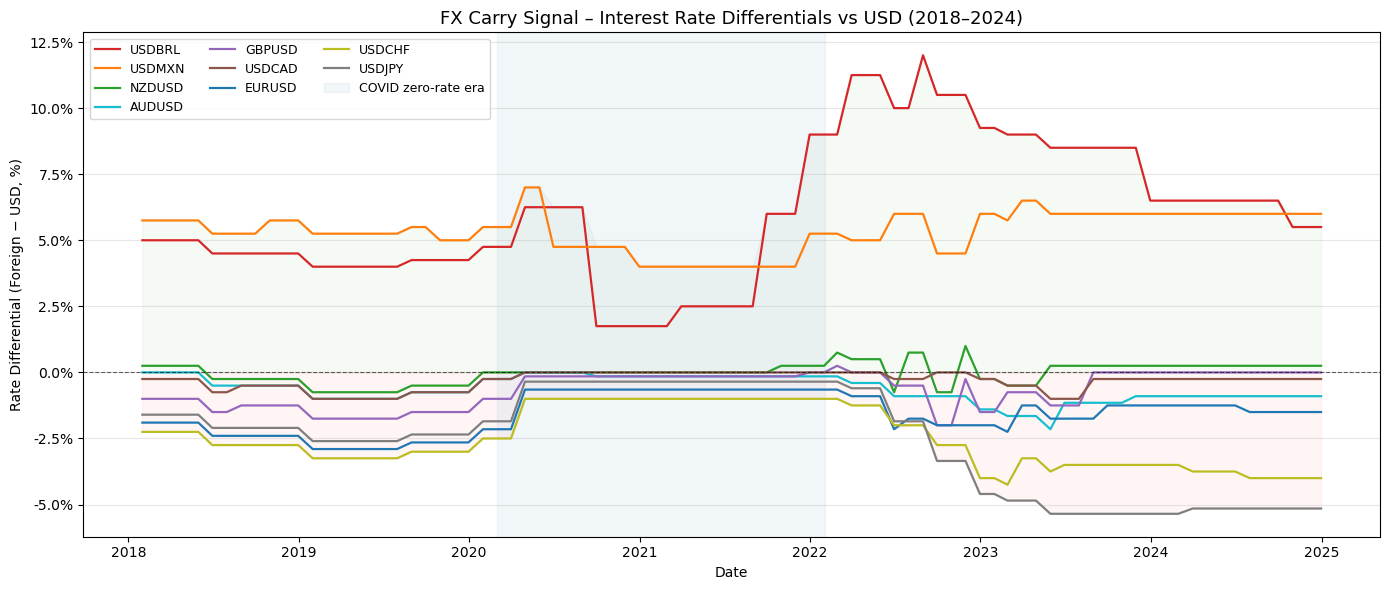

In [4]:
# Resample to month-end for a cleaner plot (rates are step-functions)
carry_m = carry.resample("ME").last()

# Colour palette: warm = high yielders, cool = low yielders / funding
COLOURS = {
    "USDBRL": "#d62728",   # red     – EM high yielder
    "USDMXN": "#ff7f0e",   # orange  – EM high yielder
    "NZDUSD": "#2ca02c",   # green   – Antipodean
    "AUDUSD": "#17becf",   # teal    – Antipodean
    "GBPUSD": "#9467bd",   # purple  – G10 mid
    "USDCAD": "#8c564b",   # brown   – G10 mid
    "EURUSD": "#1f77b4",   # blue    – G10 low → mid
    "USDCHF": "#bcbd22",   # yellow  – traditional funding
    "USDJPY": "#7f7f7f",   # grey    – classic funding
}

fig, ax = plt.subplots(figsize=(14, 6))

for pair, colour in COLOURS.items():
    ax.plot(carry_m.index, carry_m[pair], label=pair, color=colour, linewidth=1.6)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.fill_between(carry_m.index, 0, carry_m.max(axis=1), alpha=0.04, color="green")
ax.fill_between(carry_m.index, carry_m.min(axis=1), 0,  alpha=0.04, color="red")

# Shade COVID rate-cut period
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2022-02-01"),
           alpha=0.07, color="steelblue", label="COVID zero-rate era")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
ax.set_xlabel("Date")
ax.set_ylabel("Rate Differential (Foreign − USD, %)")
ax.set_title("FX Carry Signal – Interest Rate Differentials vs USD (2018–2024)", fontsize=13)
ax.legend(ncol=3, fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3b  Facet grid – one panel per currency pair

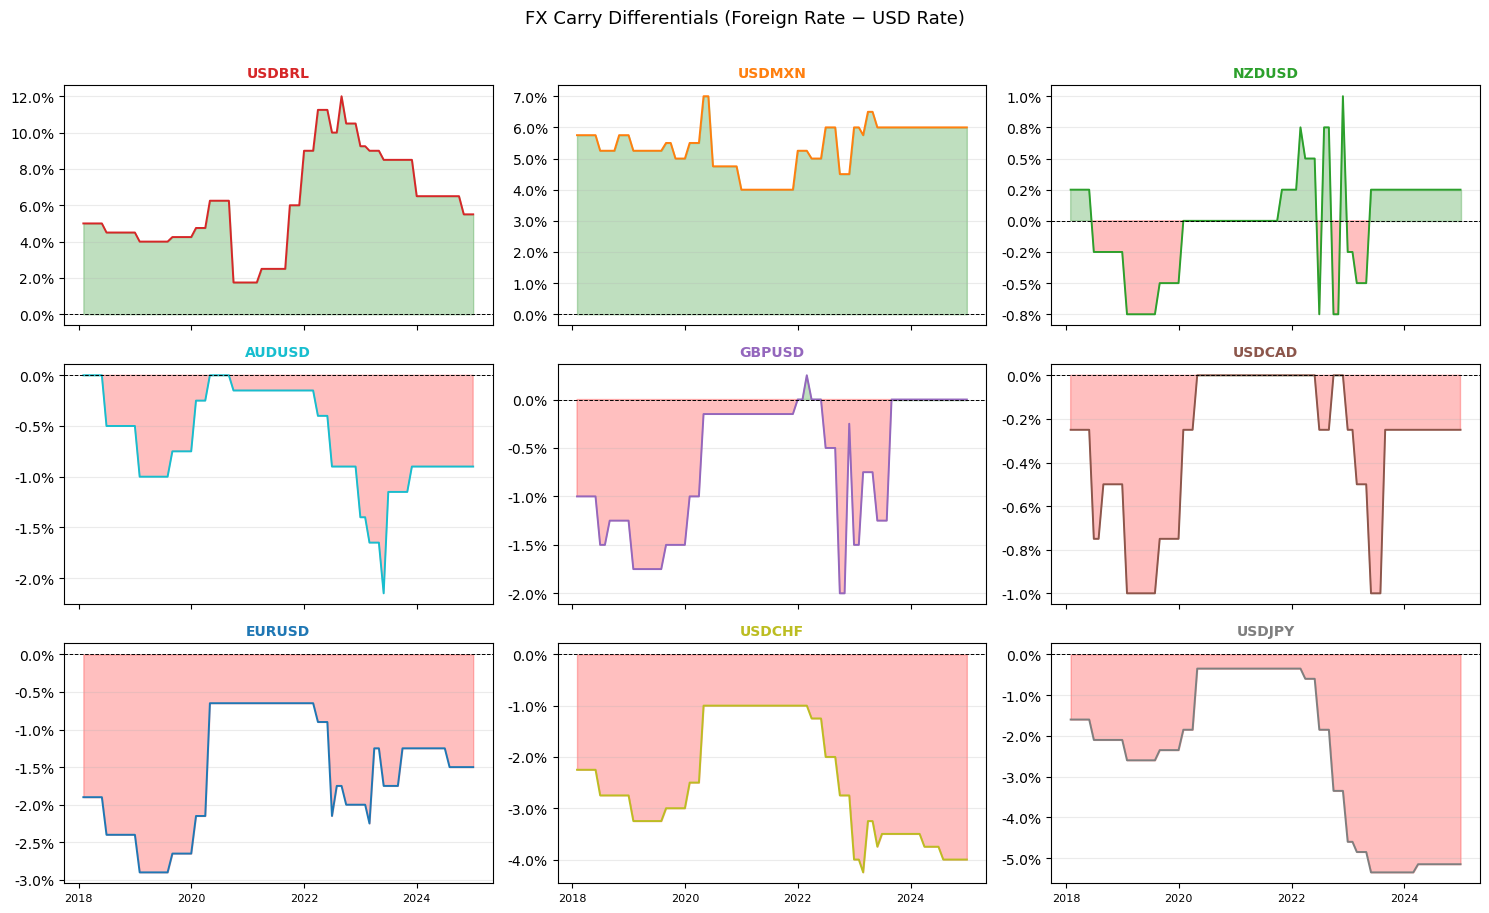

In [5]:
pairs = list(COLOURS.keys())
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
axes_flat = axes.flatten()

for ax, pair in zip(axes_flat, pairs):
    colour = COLOURS[pair]
    s = carry_m[pair]
    ax.plot(s.index, s, color=colour, linewidth=1.4)
    ax.fill_between(s.index, 0, s, where=(s >= 0), alpha=0.25, color="green", interpolate=True)
    ax.fill_between(s.index, 0, s, where=(s <  0), alpha=0.25, color="red",   interpolate=True)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(pair, fontsize=10, fontweight="bold", color=colour)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("FX Carry Differentials (Foreign Rate − USD Rate)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4  Snapshot: Current Carry Ranking

Rank currencies from highest to lowest carry differential at the latest date in the dataset.

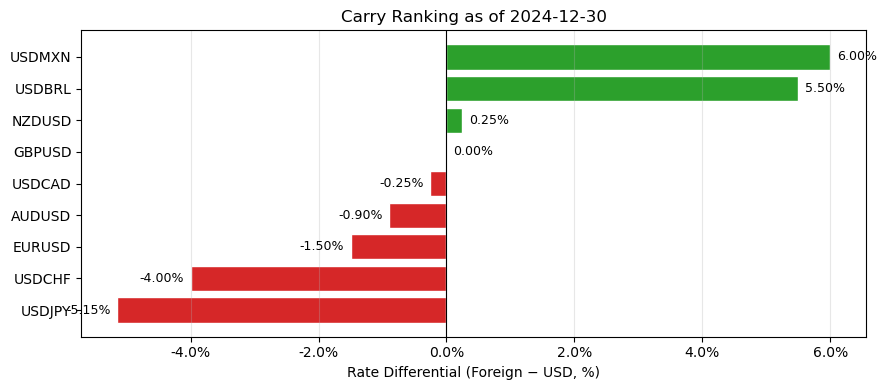


High yielders (long):
USDMXN    6.00
USDBRL    5.50
NZDUSD    0.25

Funding currencies (short):
GBPUSD    0.00
USDCAD   -0.25
AUDUSD   -0.90
EURUSD   -1.50
USDCHF   -4.00
USDJPY   -5.15


In [6]:
latest = carry.iloc[-1].sort_values(ascending=False)
latest_date = carry.index[-1].date()

fig, ax = plt.subplots(figsize=(9, 4))
colours_bar = ["#2ca02c" if v >= 0 else "#d62728" for v in latest.values]
bars = ax.barh(latest.index[::-1], latest.values[::-1], color=colours_bar[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
ax.set_xlabel("Rate Differential (Foreign − USD, %)")
ax.set_title(f"Carry Ranking as of {latest_date}", fontsize=12)
for bar, val in zip(bars[::-1], latest.values):
    xpos = val + 0.1 if val >= 0 else val - 0.1
    ha   = "left"  if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", ha=ha, fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHigh yielders (long):")
print(latest[latest > 0].to_string())
print("\nFunding currencies (short):")
print(latest[latest <= 0].to_string())

## 5  Rank-Based Carry Portfolio

### 5a  Rank signals and build weights

In [7]:
from signals import rank_carry_signals
from portfolio import weight_by_signal

# Build rank-based signals: long top 3, short bottom 3
ranked_signals = rank_carry_signals(carry, top_n=3)

# Convert to dollar-neutral weights
weights = weight_by_signal(ranked_signals)

print("Signal value counts (should be +1, 0, -1 only):")
print(ranked_signals.stack().value_counts().sort_index())

print("\nWeight sum per row (should all be ~0.0 — dollar neutral):")
print(weights.sum(axis=1).describe().round(6))

print("\nGross exposure per row (should all be ~2.0 — 100% long + 100% short):")
print(weights.abs().sum(axis=1).describe().round(4))

weights.tail()

Signal value counts (should be +1, 0, -1 only):
-1    5475
 0    5475
 1    5475
Name: count, dtype: int64

Weight sum per row (should all be ~0.0 — dollar neutral):
count    1825.0
mean       -0.0
std         0.0
min        -0.0
25%        -0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

Gross exposure per row (should all be ~2.0 — 100% long + 100% short):
count    1825.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
dtype: float64


,AUDUSD,NZDUSD,GBPUSD,EURUSD,USDJPY,USDCHF,USDCAD,USDMXN,USDBRL
Date,,,,,,,,,
2024-12-24,0.0,0.333333,0.0,-0.333333,-0.333333,-0.333333,0.0,0.333333,0.333333
2024-12-25,0.0,0.333333,0.0,-0.333333,-0.333333,-0.333333,0.0,0.333333,0.333333
2024-12-26,0.0,0.333333,0.0,-0.333333,-0.333333,-0.333333,0.0,0.333333,0.333333
2024-12-27,0.0,0.333333,0.0,-0.333333,-0.333333,-0.333333,0.0,0.333333,0.333333
2024-12-30,0.0,0.333333,0.0,-0.333333,-0.333333,-0.333333,0.0,0.333333,0.333333


### 5b  Weight Heatmap over time

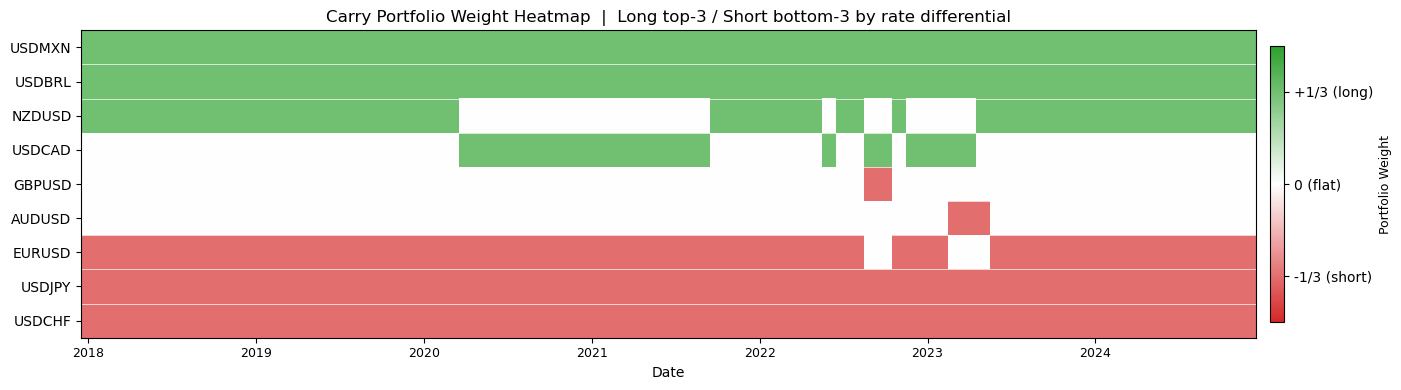

In [8]:
import matplotlib.colors as mcolors

# Resample to month-end to keep the heatmap readable
weights_m = weights.resample("ME").last()

# Order columns: sort by mean weight so longs appear at the top, shorts at the bottom
col_order = weights_m.mean().sort_values(ascending=False).index
weights_sorted = weights_m[col_order]

fig, ax = plt.subplots(figsize=(15, 4))

# Diverging colormap: green = long (+1/3), white = flat (0), red = short (-1/3)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "carry_weights", ["#d62728", "#ffffff", "#2ca02c"]
)
im = ax.imshow(
    weights_sorted.T.values,
    aspect="auto",
    cmap=cmap,
    vmin=-0.5,
    vmax=0.5,
    interpolation="nearest",
)

# X-axis: dates
x_ticks = range(0, len(weights_m), 12)
ax.set_xticks(list(x_ticks))
ax.set_xticklabels(
    [weights_m.index[i].strftime("%Y") for i in x_ticks],
    fontsize=9,
)

# Y-axis: currency pairs
ax.set_yticks(range(len(col_order)))
ax.set_yticklabels(col_order, fontsize=10)

# Colourbar
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.01, shrink=0.9)
cbar.set_label("Portfolio Weight", fontsize=9)
cbar.set_ticks([-1/3, 0, 1/3])
cbar.set_ticklabels(["-1/3 (short)", "0 (flat)", "+1/3 (long)"])

ax.set_xlabel("Date")
ax.set_title(
    "Carry Portfolio Weight Heatmap  |  Long top-3 / Short bottom-3 by rate differential",
    fontsize=12,
)

# Light grid lines between rows
for y in range(len(col_order) - 1):
    ax.axhline(y + 0.5, color="white", linewidth=0.5)

plt.tight_layout()
plt.show()

## 6  Risk Analysis

### 6a  Run backtest

In [9]:
import numpy as np
from backtest import run_backtest_ts_momentum

# Normalise all spot rates to "USD per 1 unit of foreign currency"
USD_BASE_PAIRS = ["USDJPY", "USDCHF", "USDCAD", "USDMXN", "USDBRL"]
spot_norm = spot_df.copy()
for pair in USD_BASE_PAIRS:
    spot_norm[pair] = 1.0 / spot_norm[pair]

COMMON = dict(prices=spot_norm, signals=ranked_signals, weights=weights, tc_bps=5)

# Baseline: spot price return only (no interest income)
results_price_only = run_backtest_ts_momentum(**COMMON)

# Full carry: spot return + daily interest accrual
# `carry` has per-pair differentials in % p.a. (output of calculate_fx_carry_signal)
results = run_backtest_ts_momentum(**COMMON, rates_df=carry)

# Sanity-check the interest income magnitude
ann_carry_income = results["Interest_Income"].mean() * 252
print(f"Average annualised interest income : {ann_carry_income:.2%}")
print(f"Final equity (price only)          : {results_price_only['Cumulative_Equity'].iloc[-1]:.3f}x")
print(f"Final equity (with carry)          : {results['Cumulative_Equity'].iloc[-1]:.3f}x")

# Show a sample of the interest breakdown for a recent date
results[["Price_Return", "Interest_Income", "Gross_Daily_Return", "Net_Daily_Return"]].tail(5).applymap(lambda x: f"{x:.5%}")

Average annualised interest income : 4.13%
Final equity (price only)          : 0.819x
Final equity (with carry)          : 1.105x


,Price_Return,Interest_Income,Gross_Daily_Return,Net_Daily_Return
Date,,,,
2024-12-24,-0.37747%,0.02074%,-0.35673%,-0.35673%
2024-12-25,0.19850%,0.02074%,0.21925%,0.21925%
2024-12-26,-0.04381%,0.02074%,-0.02307%,-0.02307%
2024-12-27,-0.00844%,0.02074%,0.01230%,0.01230%
2024-12-30,-0.22535%,0.02074%,-0.20461%,-0.20461%


### 6b  Performance metrics

In [10]:
def performance_metrics(daily_returns: pd.Series, label: str = "") -> dict:
    """Computes annualised return, vol, Sharpe (rf=0), and max drawdown."""
    ann_return = np.exp(daily_returns.mean() * 252) - 1
    ann_vol    = daily_returns.std() * np.sqrt(252)
    sharpe     = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity   = np.exp(daily_returns.cumsum())
    max_dd   = (equity / equity.cummax() - 1).min()

    return {
        "Strategy":        label,
        "Ann. Return":     f"{ann_return:.2%}",
        "Ann. Volatility": f"{ann_vol:.2%}",
        "Sharpe Ratio":    f"{sharpe:.2f}",
        "Max Drawdown":    f"{max_dd:.2%}",
    }

# ── Three strategies ─────────────────────────────────────────────────────────
market = load_prices("market_prices.csv")
spy = np.log(market["SPY"] / market["SPY"].shift(1)).dropna()
spy = spy.reindex(results.index).dropna()

rows = [
    performance_metrics(results_price_only["Net_Daily_Return"], "Carry (price only, no interest)"),
    performance_metrics(results["Net_Daily_Return"],            "Carry (price + interest income)"),
    performance_metrics(spy,                                    "SPY (S&P 500)"),
]
metrics_df = pd.DataFrame(rows).set_index("Strategy")

# Highlight which Sharpe values are positive
def highlight_sharpe(val):
    try:
        v = float(val)
        return "color: green; font-weight: bold" if v > 0 else "color: red"
    except (ValueError, TypeError):
        return ""

metrics_df.style.applymap(highlight_sharpe, subset=["Sharpe Ratio"])

,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Strategy,,,,
"Carry (price only, no interest)",-2.72%,9.47%,-0.29,-26.90%
Carry (price + interest income),1.38%,9.47%,0.15,-21.24%
SPY (S&P 500),13.76%,19.54%,0.70,-33.72%


### 6c  Cumulative equity vs SPY — with crash highlights

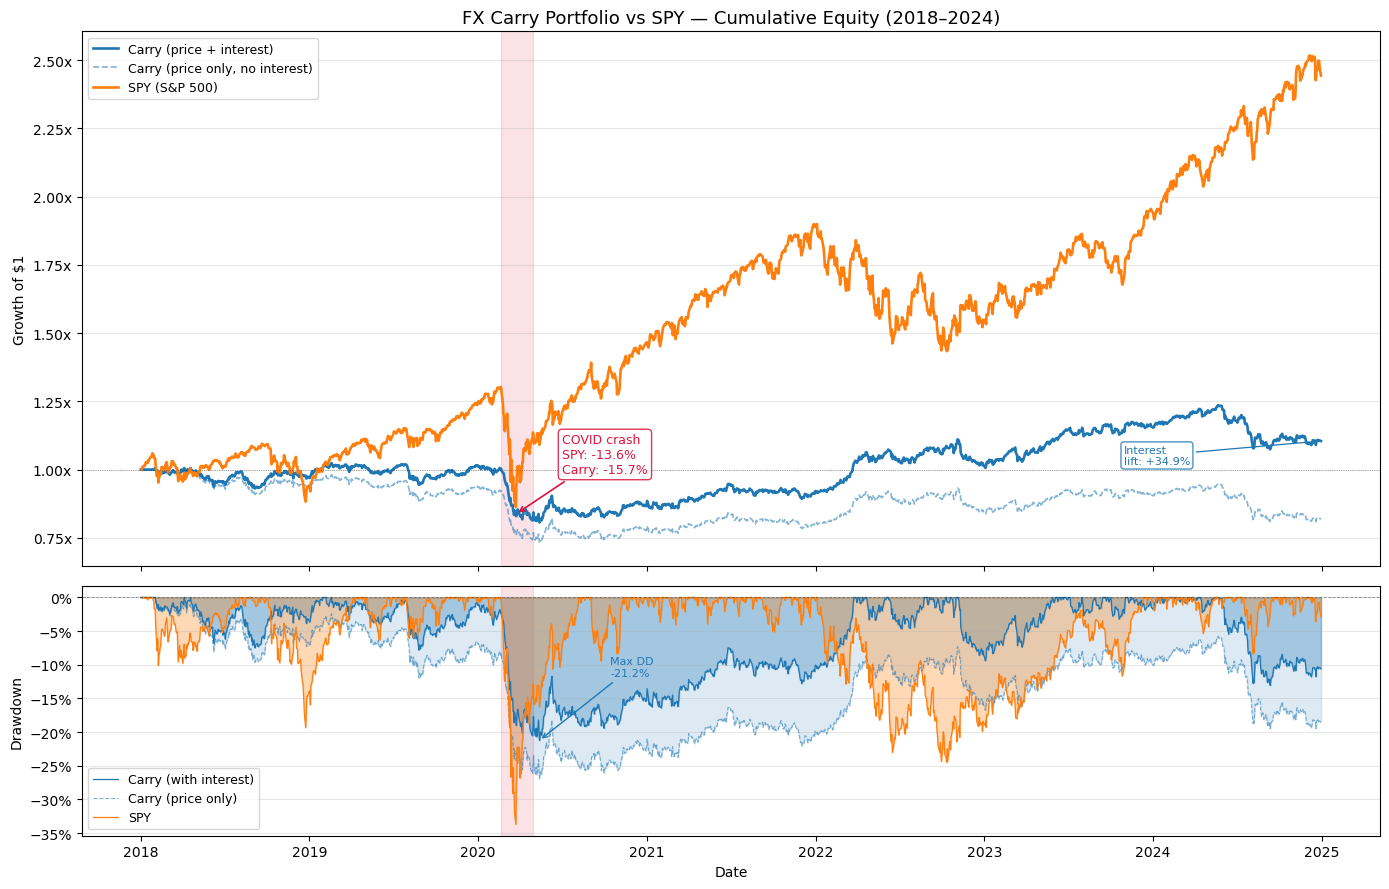

───────────────────────────────────────────────────────
COVID window: 2020-02-19 → 2020-04-30
  SPY return            : -13.64%
  Carry return          : -15.70%
  Verdict               : ✗ FAILED TO PROTECT

Interest income lifted final equity by: +34.9%
───────────────────────────────────────────────────────


In [11]:
# ── Rebuild normalised equity curves starting at 1.0 on the first shared date ──
shared_start = max(results.index[0], spy.index[0])

carry_eq       = results["Cumulative_Equity"]
carry_eq       = carry_eq / carry_eq.loc[shared_start]

price_only_eq  = results_price_only["Cumulative_Equity"]
price_only_eq  = price_only_eq / price_only_eq.loc[shared_start]

spy_eq         = np.exp(spy.cumsum())
spy_eq         = spy_eq / spy_eq.loc[shared_start]

# ── Drawdown series ──────────────────────────────────────────────────────────
carry_dd      = carry_eq      / carry_eq.cummax()      - 1
price_only_dd = price_only_eq / price_only_eq.cummax() - 1
spy_dd        = spy_eq        / spy_eq.cummax()        - 1

# ── COVID window ──────────────────────────────────────────────────────────────
COVID_START = pd.Timestamp("2020-02-19")
COVID_END   = pd.Timestamp("2020-04-30")

def period_return(eq, t0, t1):
    return eq.loc[t1] / eq.loc[t0] - 1

spy_covid_dd   = period_return(spy_eq,   COVID_START, COVID_END)
carry_covid_dd = period_return(carry_eq, COVID_START, COVID_END)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={"height_ratios": [3, 1.4]},
                                sharex=True)
fig.subplots_adjust(hspace=0.08)

# --- Top panel: cumulative equity --------------------------------------------
ax1.plot(carry_eq.index,      carry_eq,      color="#1f77b4", linewidth=1.9,
         label="Carry (price + interest)")
ax1.plot(price_only_eq.index, price_only_eq, color="#1f77b4", linewidth=1.2,
         linestyle="--", alpha=0.55, label="Carry (price only, no interest)")
ax1.plot(spy_eq.index,        spy_eq,        color="#ff7f0e", linewidth=1.9,
         label="SPY (S&P 500)")
ax1.axhline(1, color="black", linewidth=0.6, linestyle=":", alpha=0.4)

# Shade COVID window
ax1.axvspan(COVID_START, COVID_END, alpha=0.12, color="crimson", zorder=0)
ax1.annotate(
    f"COVID crash\nSPY: {spy_covid_dd:+.1%}\nCarry: {carry_covid_dd:+.1%}",
    xy=(pd.Timestamp("2020-03-23"), carry_eq.loc["2020-03-23"]),
    xytext=(pd.Timestamp("2020-07-01"), carry_eq.loc["2020-03-23"] * 1.18),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2),
    color="crimson",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.85),
)

# Annotate the gap between price-only and full-carry at end of period
last_date   = carry_eq.index[-1]
gap_pct     = (carry_eq.iloc[-1] / price_only_eq.iloc[-1] - 1)
mid_y       = (carry_eq.iloc[-1] + price_only_eq.iloc[-1]) / 2
ax1.annotate(
    f"Interest\nlift: {gap_pct:+.1%}",
    xy=(last_date, carry_eq.iloc[-1]),
    xytext=(last_date - pd.DateOffset(months=14), mid_y * 1.06),
    fontsize=8, color="#1f77b4",
    arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=0.9),
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#1f77b4", alpha=0.8),
)

ax1.set_ylabel("Growth of $1", fontsize=10)
ax1.set_title("FX Carry Portfolio vs SPY — Cumulative Equity (2018–2024)", fontsize=13)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(axis="y", alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2fx"))

# --- Bottom panel: drawdown --------------------------------------------------
ax2.fill_between(carry_dd.index,      carry_dd,      0, alpha=0.30, color="#1f77b4")
ax2.fill_between(price_only_dd.index, price_only_dd, 0, alpha=0.15, color="#1f77b4")
ax2.fill_between(spy_dd.index,        spy_dd,        0, alpha=0.30, color="#ff7f0e")
ax2.plot(carry_dd.index,      carry_dd,      color="#1f77b4", linewidth=0.9,
         label="Carry (with interest)")
ax2.plot(price_only_dd.index, price_only_dd, color="#1f77b4", linewidth=0.8,
         linestyle="--", alpha=0.55, label="Carry (price only)")
ax2.plot(spy_dd.index,        spy_dd,        color="#ff7f0e", linewidth=0.9,
         label="SPY")

worst_dd_date = carry_dd.idxmin()
ax2.annotate(
    f"Max DD\n{carry_dd.min():.1%}",
    xy=(worst_dd_date, carry_dd.min()),
    xytext=(worst_dd_date + pd.DateOffset(months=5), carry_dd.min() * 0.55),
    fontsize=8, color="#1f77b4",
    arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.0),
)

ax2.axvspan(COVID_START, COVID_END, alpha=0.12, color="crimson", zorder=0)
ax2.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.4)
ax2.set_ylabel("Drawdown", fontsize=10)
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.legend(fontsize=9, loc="lower left")
ax2.grid(axis="y", alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# ── COVID period summary ──────────────────────────────────────────────────────
print("─" * 55)
print(f"COVID window: {COVID_START.date()} → {COVID_END.date()}")
print(f"  SPY return            : {spy_covid_dd:+.2%}")
print(f"  Carry return          : {carry_covid_dd:+.2%}")
verdict = "✓ PROTECTED" if carry_covid_dd > spy_covid_dd else "✗ FAILED TO PROTECT"
print(f"  Verdict               : {verdict}")
print(f"\nInterest income lifted final equity by: {gap_pct:+.1%}")
print("─" * 55)

## 7  Volatility-Scaled Carry

### 7a  Build vol-scaled weights and run backtest

**Intuition:** equal-weighted carry gives each *currency* the same notional exposure.
EM currencies (MXN, BRL) are far more volatile than G10 (JPY, CHF), so they dominate the portfolio's P&L variance.
Inverse-volatility weighting lets each *position* contribute equal risk, smoothing drawdowns.

In [12]:
from risk import calculate_vol_scaled_weights

# Build inverse-vol weights (direction from equal-weighted signals, target 10% ann. vol)
# `weights` = equal-weighted output of weight_by_signal — we only use its sign here
vol_scaled_weights = calculate_vol_scaled_weights(
    prices_df=spot_norm,
    signal_weights_df=weights,
    target_vol=0.10,
    vol_window=60,
)

# Sanity checks
print("Dollar-neutral check — net weight per row (should be ~0):")
print(vol_scaled_weights.sum(axis=1).describe().round(6))

print("\nGross exposure per row (varies with vol targeting, target ≈ 2 × (ann_vol / asset_vol)):")
print(vol_scaled_weights.abs().sum(axis=1).describe().round(3))

# Run backtest with interest income
results_volscaled = run_backtest_ts_momentum(
    prices=spot_norm,
    signals=ranked_signals,
    weights=vol_scaled_weights,
    tc_bps=5,
    rates_df=carry,
)

ann_carry_vs = results_volscaled["Interest_Income"].mean() * 252
print(f"\nVol-scaled — avg annualised interest income : {ann_carry_vs:.2%}")
print(f"Vol-scaled — final equity                   : {results_volscaled['Cumulative_Equity'].iloc[-1]:.3f}x")

# Show weight comparison on a recent date
print("\n── Weight comparison on last date ──")
last = vol_scaled_weights.iloc[-1].sort_values()
equal_last = weights.iloc[-1].sort_values()
pd.DataFrame({"Equal": equal_last, "Vol-Scaled": last}).round(4)

Dollar-neutral check — net weight per row (should be ~0):
count    1825.0
mean        0.0
std         0.0
min        -0.0
25%        -0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

Gross exposure per row (varies with vol targeting, target ≈ 2 × (ann_vol / asset_vol)):
count    1825.000
mean        2.609
std         0.886
min         0.000
25%         2.215
50%         2.639
75%         2.953
max         8.000
dtype: float64

Vol-scaled — avg annualised interest income : 5.03%
Vol-scaled — final equity                   : 1.010x

── Weight comparison on last date ──


,Equal,Vol-Scaled
AUDUSD,0.0000,0.0000
EURUSD,-0.3333,-0.4803
GBPUSD,0.0000,0.0000
NZDUSD,0.3333,0.5285
USDBRL,0.3333,0.3300
USDCAD,0.0000,0.0000
USDCHF,-0.3333,-0.5199
USDJPY,-0.3333,-0.3511
USDMXN,0.3333,0.4928


### 7b  Performance comparison

In [13]:
rows_compare = [
    performance_metrics(results["Net_Daily_Return"],          "Equal-Weighted Carry"),
    performance_metrics(results_volscaled["Net_Daily_Return"],"Vol-Scaled Carry (target 10%)"),
    performance_metrics(spy,                                  "SPY (S&P 500)"),
]
compare_df = pd.DataFrame(rows_compare).set_index("Strategy")

# Colour-code the Sharpe column and highlight the better carry strategy
def style_table(val, col_name):
    if col_name == "Sharpe Ratio":
        try:
            v = float(val)
            return "color: green; font-weight: bold" if v > 0 else "color: red"
        except (ValueError, TypeError):
            pass
    return ""

compare_df.style.apply(
    lambda col: [style_table(v, col.name) for v in col], axis=0
)

,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Strategy,,,,
Equal-Weighted Carry,1.38%,9.47%,0.15,-21.24%
Vol-Scaled Carry (target 10%),0.14%,11.64%,0.01,-30.38%
SPY (S&P 500),13.76%,19.54%,0.70,-33.72%


### 7c  Equity & drawdown comparison

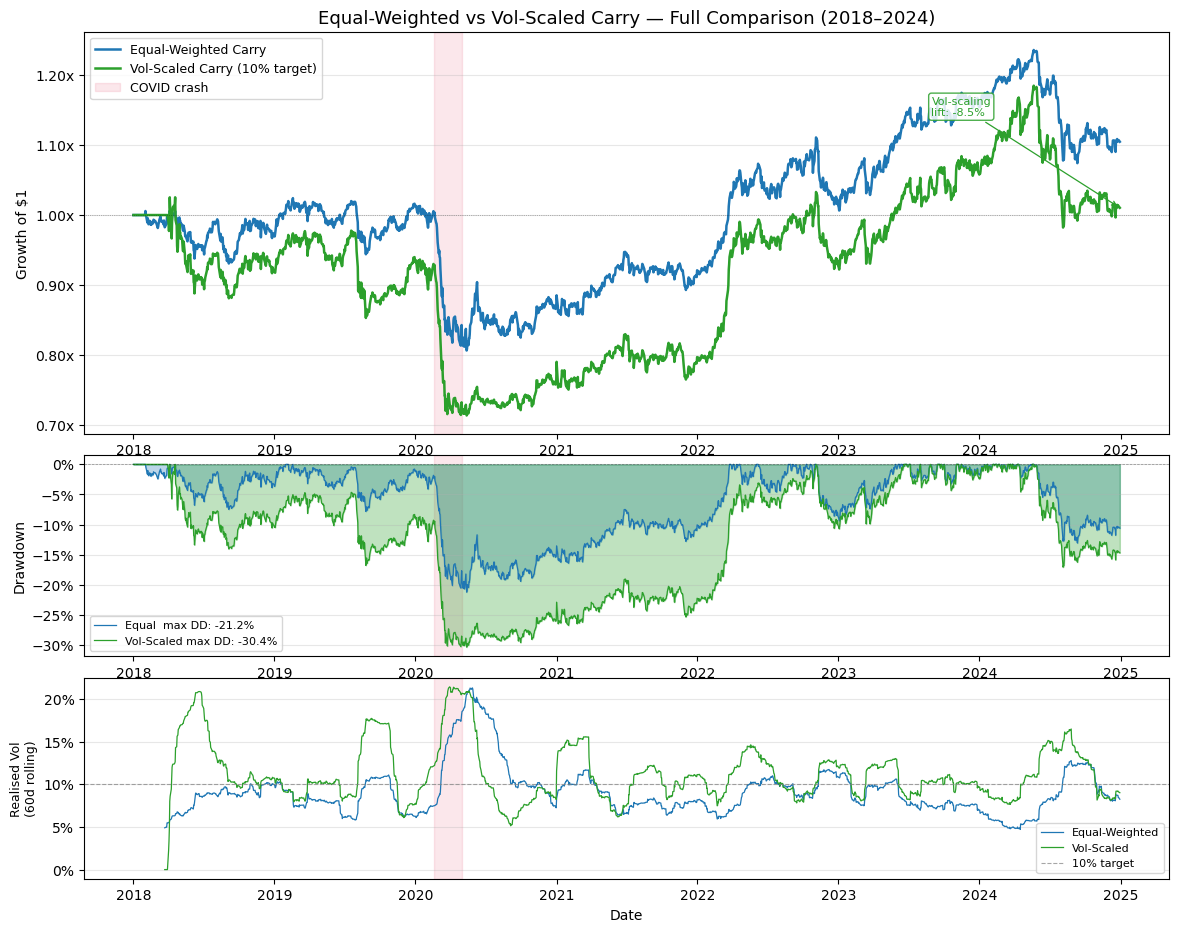

──────────────────────────────────────────────────
COVID crash (2020-02-19 → 2020-04-30)
  Equal-Weighted Carry : -15.70%
  Vol-Scaled Carry     : -20.64%
  Improvement          : -4.94%
──────────────────────────────────────────────────


In [14]:
import matplotlib.gridspec as gridspec

# ── Equity curves rebased to 1.0 at first shared date ────────────────────────
_start = shared_start  # defined in section 6c

eq_equal = results["Cumulative_Equity"]
eq_equal = eq_equal / eq_equal.loc[_start]

eq_vs = results_volscaled["Cumulative_Equity"]
eq_vs = eq_vs / eq_vs.loc[_start]

# ── Drawdown series ───────────────────────────────────────────────────────────
dd_equal = eq_equal / eq_equal.cummax() - 1
dd_vs    = eq_vs    / eq_vs.cummax()    - 1

# ── Rolling 60-day vol of net returns ─────────────────────────────────────────
rv_equal = results["Net_Daily_Return"].rolling(60).std() * np.sqrt(252)
rv_vs    = results_volscaled["Net_Daily_Return"].rolling(60).std() * np.sqrt(252)

# ── Plot: 3 rows ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1.5, 1.5], hspace=0.08)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

C_EQ = "#1f77b4"   # blue  – equal weighted
C_VS = "#2ca02c"   # green – vol scaled

# --- Row 1: Cumulative equity ------------------------------------------------
ax1.plot(eq_equal.index, eq_equal, color=C_EQ, linewidth=1.8, label="Equal-Weighted Carry")
ax1.plot(eq_vs.index,    eq_vs,    color=C_VS, linewidth=1.8, label="Vol-Scaled Carry (10% target)")
ax1.axhline(1, color="black", linewidth=0.5, linestyle=":", alpha=0.5)

# Shade COVID crash
ax1.axvspan(COVID_START, COVID_END, alpha=0.10, color="crimson", zorder=0, label="COVID crash")

# Annotation: lift from vol scaling at end of period
_end      = eq_equal.index[-1]
_gap      = eq_vs.iloc[-1] / eq_equal.iloc[-1] - 1
_mid_y    = (eq_equal.iloc[-1] + eq_vs.iloc[-1]) / 2
ax1.annotate(
    f"Vol-scaling\nlift: {_gap:+.1%}",
    xy=(_end, eq_vs.iloc[-1]),
    xytext=(_end - pd.DateOffset(months=16), _mid_y * 1.08),
    fontsize=8, color=C_VS,
    arrowprops=dict(arrowstyle="->", color=C_VS, lw=0.9),
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=C_VS, alpha=0.85),
)
ax1.set_ylabel("Growth of $1", fontsize=10)
ax1.set_title("Equal-Weighted vs Vol-Scaled Carry — Full Comparison (2018–2024)", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2fx"))

# --- Row 2: Drawdown ---------------------------------------------------------
ax2.fill_between(dd_equal.index, dd_equal, 0, alpha=0.30, color=C_EQ)
ax2.fill_between(dd_vs.index,    dd_vs,    0, alpha=0.30, color=C_VS)
ax2.plot(dd_equal.index, dd_equal, color=C_EQ, linewidth=0.9,
         label=f"Equal  max DD: {dd_equal.min():.1%}")
ax2.plot(dd_vs.index,    dd_vs,    color=C_VS, linewidth=0.9,
         label=f"Vol-Scaled max DD: {dd_vs.min():.1%}")
ax2.axvspan(COVID_START, COVID_END, alpha=0.10, color="crimson", zorder=0)
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax2.set_ylabel("Drawdown", fontsize=10)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.legend(fontsize=8, loc="lower left")
ax2.grid(axis="y", alpha=0.3)

# --- Row 3: Realised volatility ----------------------------------------------
ax3.plot(rv_equal.index, rv_equal, color=C_EQ, linewidth=0.9, label="Equal-Weighted")
ax3.plot(rv_vs.index,    rv_vs,    color=C_VS, linewidth=0.9, label="Vol-Scaled")
ax3.axhline(0.10, color="gray", linewidth=0.8, linestyle="--", alpha=0.7, label="10% target")
ax3.axvspan(COVID_START, COVID_END, alpha=0.10, color="crimson", zorder=0)
ax3.set_ylabel("Realised Vol\n(60d rolling)", fontsize=9)
ax3.set_xlabel("Date")
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax3.legend(fontsize=8)
ax3.grid(axis="y", alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# ── COVID drawdown comparison ──────────────────────────────────────────────────
covid_eq = period_return(eq_equal, COVID_START, COVID_END)
covid_vs = period_return(eq_vs,    COVID_START, COVID_END)
print("─" * 50)
print(f"COVID crash ({COVID_START.date()} → {COVID_END.date()})")
print(f"  Equal-Weighted Carry : {covid_eq:+.2%}")
print(f"  Vol-Scaled Carry     : {covid_vs:+.2%}")
print(f"  Improvement          : {covid_vs - covid_eq:+.2%}")
print("─" * 50)